# Model Training

In [14]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports loaded.")

Imports loaded.


In [ ]:
df = pd.read_csv("../data/processed/building_level.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['accessibility_class'].value_counts()}")

DROP_COLS = [
    "num_accessible_services",   # collinear with accessible_service_ratio
    "num_critical_services",     # collinear with critical_upper_ratio
    "num_accessible_critical",   # collinear with accessible_critical_ratio
    "num_services_ground",       # collinear with upper_service_ratio
    "num_services_upper",        # collinear with upper_service_ratio
    "num_critical_upper",        # collinear with critical_upper_ratio
    "ramps_present",             # not in scoring formula
]

TARGET = "accessibility_class"

feature_df = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print(f"\nSelected features ({feature_df.shape[1]}):")
print(list(feature_df.columns))

Dataset shape: (509, 20)

Class distribution:
accessibility_class
medium    229
high      180
low       100
Name: count, dtype: int64

Selected features (12):
['site_type', 'total_floors', 'step_free_entrance', 'handrails_present', 'elevator_present', 'total_services', 'avg_clear_signage', 'avg_high_contrast', 'accessible_service_ratio', 'upper_service_ratio', 'critical_upper_ratio', 'accessible_critical_ratio']


In [ ]:
categorical_features = ["site_type"]
numeric_features = [
    col for col in feature_df.columns if col not in categorical_features
]

print(f"Categorical: {categorical_features}")
print(f"Numeric ({len(numeric_features)}): {numeric_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ]
)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print(f"\nTarget classes: {list(class_names)}")
print(f"Encoded mapping: {dict(zip(class_names, label_encoder.transform(class_names)))}")

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

Categorical: ['site_type']
Numeric (11): ['total_floors', 'step_free_entrance', 'handrails_present', 'elevator_present', 'total_services', 'avg_clear_signage', 'avg_high_contrast', 'accessible_service_ratio', 'upper_service_ratio', 'critical_upper_ratio', 'accessible_critical_ratio']

Target classes: ['high', 'low', 'medium']
Encoded mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Train: 407 samples
Test:  102 samples

Train class distribution: {np.int64(0): np.int64(144), np.int64(1): np.int64(80), np.int64(2): np.int64(183)}
Test class distribution:  {np.int64(0): np.int64(36), np.int64(1): np.int64(20), np.int64(2): np.int64(46)}


In [ ]:
def evaluate_model(model, X_test, y_test, class_names, model_name="Model"):
    """Train evaluation with classification report + confusion matrix."""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{'='*50}")
    print(f"{model_name} -- Test Results")
    print(f"{'='*50}")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues")
    ax.set_title(f"{model_name} -- Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "f1_weighted": f1}

print("Evaluation helper ready.")

Evaluation helper ready.


Logistic Regression — Test Results
Accuracy:    0.9902
Weighted F1: 0.9902

Classification Report:
              precision    recall  f1-score   support

        high       0.97      1.00      0.99        36
         low       1.00      1.00      1.00        20
      medium       1.00      0.98      0.99        46

    accuracy                           0.99       102
   macro avg       0.99      0.99      0.99       102
weighted avg       0.99      0.99      0.99       102



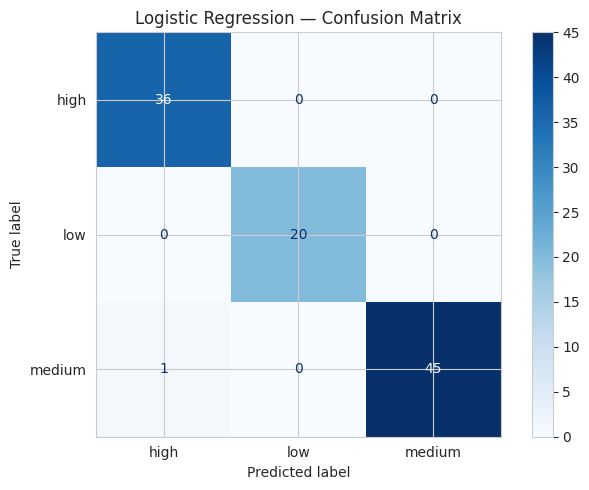

In [ ]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    )),
])

lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipeline, X_test, y_test, class_names, "Logistic Regression")

Random Forest — Test Results
Accuracy:    0.9706
Weighted F1: 0.9706

Classification Report:
              precision    recall  f1-score   support

        high       1.00      0.94      0.97        36
         low       0.95      1.00      0.98        20
      medium       0.96      0.98      0.97        46

    accuracy                           0.97       102
   macro avg       0.97      0.97      0.97       102
weighted avg       0.97      0.97      0.97       102



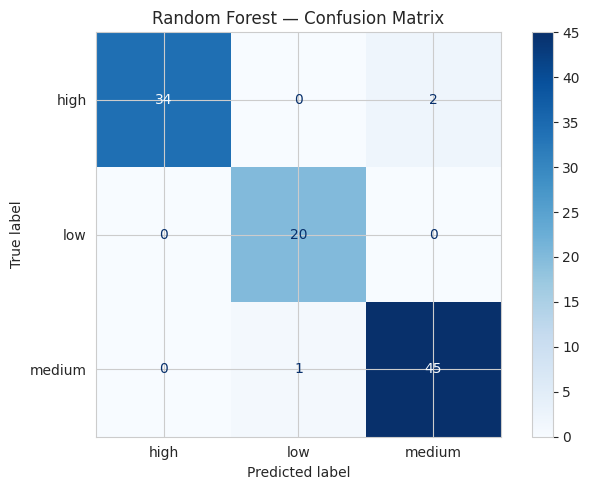

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_results = evaluate_model(rf_pipeline, X_test, y_test, class_names, "Random Forest")

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1_weighted"]

models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(
        model, feature_df, y_encoded,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = {
        "CV Accuracy": f"{scores['test_accuracy'].mean():.4f} +/- {scores['test_accuracy'].std():.4f}",
        "CV F1 (weighted)": f"{scores['test_f1_weighted'].mean():.4f} +/- {scores['test_f1_weighted'].std():.4f}",
    }

cv_df = pd.DataFrame(cv_results).T
print("Cross-Validation Results (5-fold):")
cv_df

Cross-Validation Results (5-fold):


,CV Accuracy,CV F1 (weighted)
Logistic Regression,0.9823 ± 0.0073,0.9824 ± 0.0073
Random Forest,0.9470 ± 0.0099,0.9467 ± 0.0097


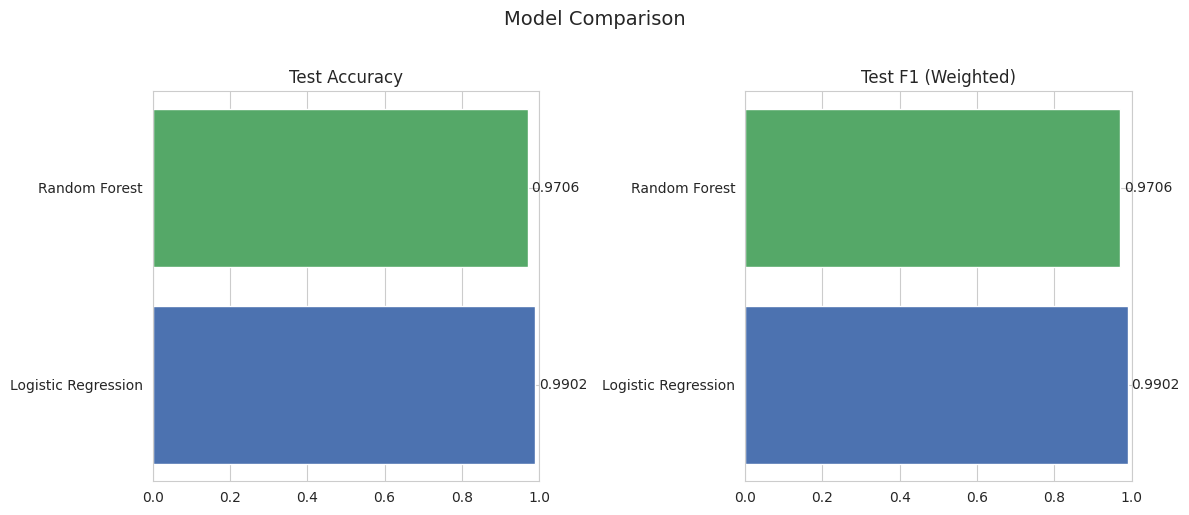

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [lr_results["accuracy"], rf_results["accuracy"]],
    "Test F1 (weighted)": [lr_results["f1_weighted"], rf_results["f1_weighted"]],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(comparison_df["Model"], comparison_df["Test Accuracy"], color=["#4C72B0", "#55A868"])
axes[0].set_xlim(0, 1)
axes[0].set_title("Test Accuracy")
for i, v in enumerate(comparison_df["Test Accuracy"]):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va="center")

axes[1].barh(comparison_df["Model"], comparison_df["Test F1 (weighted)"], color=["#4C72B0", "#55A868"])
axes[1].set_xlim(0, 1)
axes[1].set_title("Test F1 (Weighted)")
for i, v in enumerate(comparison_df["Test F1 (weighted)"]):
    axes[1].text(v + 0.01, i, f"{v:.4f}", va="center")

plt.suptitle("Model Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
cat_encoder = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

print(f"Total features after encoding: {len(all_feature_names)}")
print(all_feature_names)

Total features after encoding: 14
['total_floors', 'step_free_entrance', 'handrails_present', 'elevator_present', 'total_services', 'avg_clear_signage', 'avg_high_contrast', 'accessible_service_ratio', 'upper_service_ratio', 'critical_upper_ratio', 'accessible_critical_ratio', 'site_type_hospital', 'site_type_library', 'site_type_school']


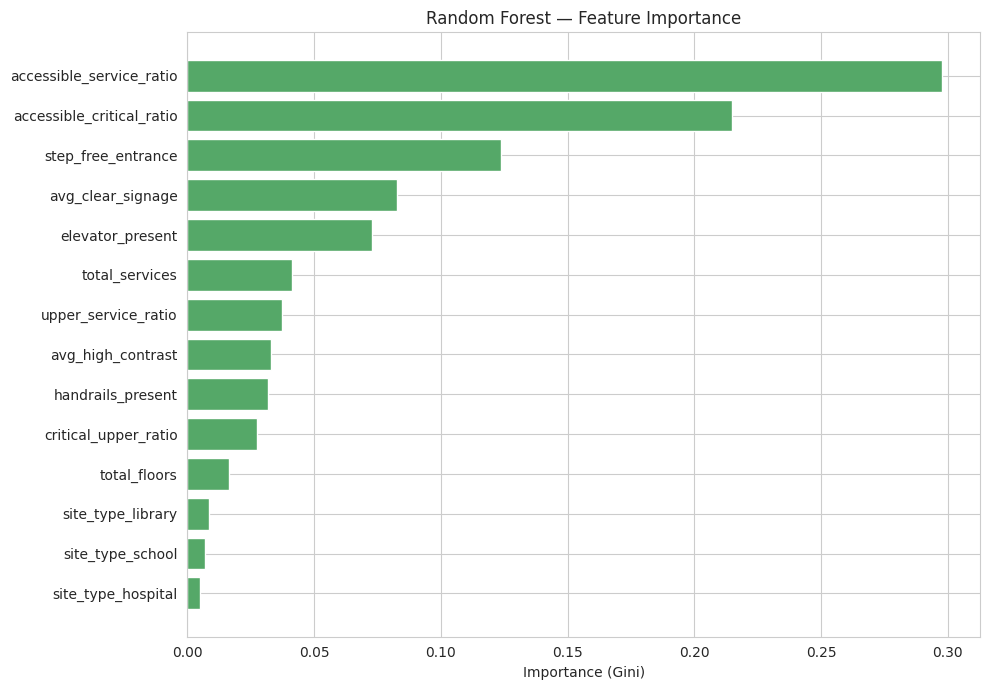

In [ ]:
rf_importances = rf_pipeline.named_steps["classifier"].feature_importances_
rf_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(rf_imp_df["feature"], rf_imp_df["importance"], color="#55A868")
ax.set_title("Random Forest -- Feature Importance")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

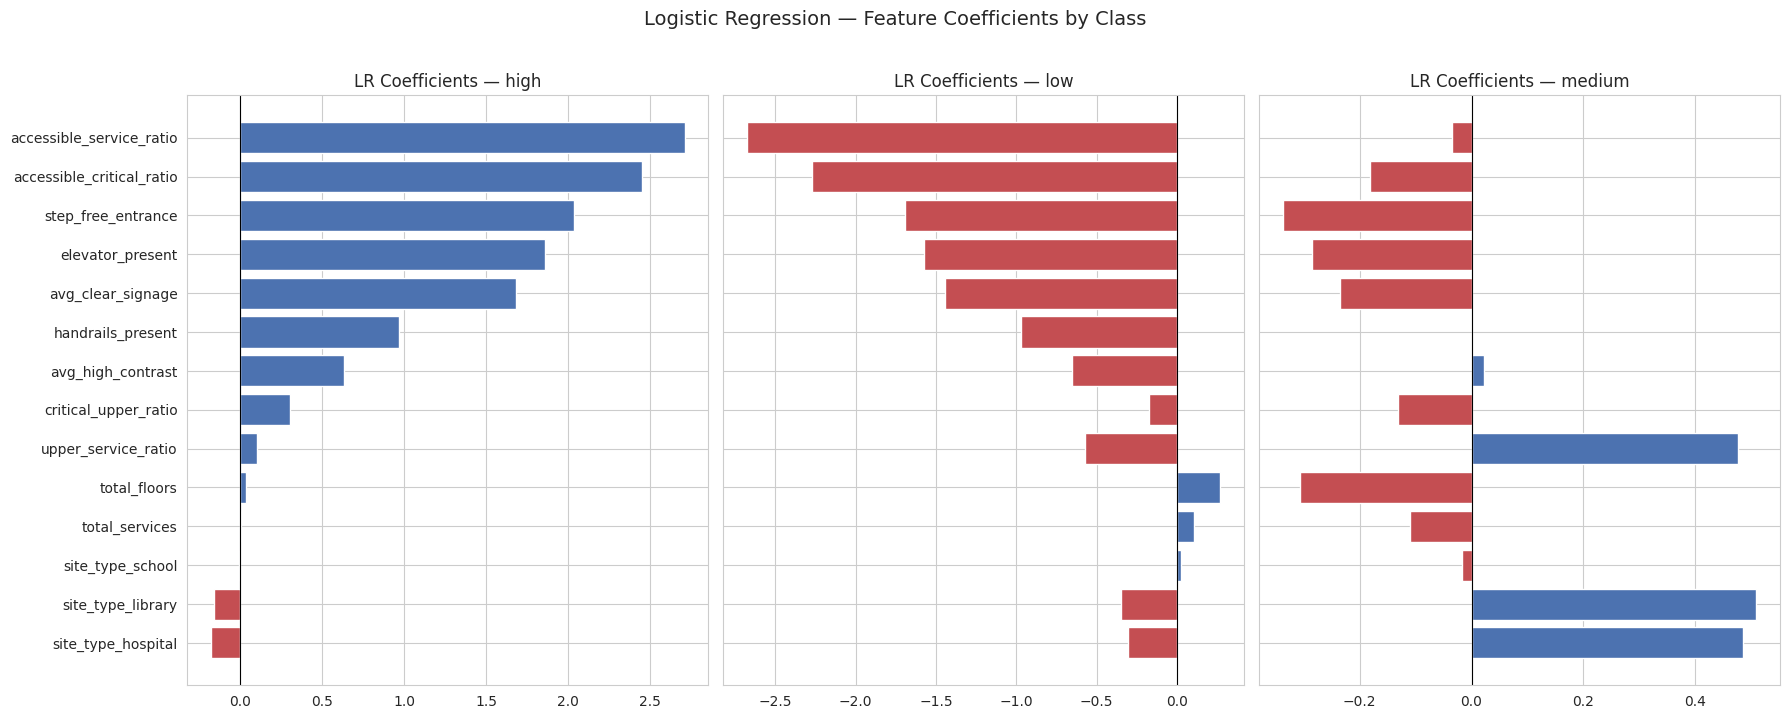

In [ ]:
lr_coefs = lr_pipeline.named_steps["classifier"].coef_
lr_coef_df = pd.DataFrame(
    lr_coefs, columns=all_feature_names, index=class_names
).T

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
for i, cls in enumerate(class_names):
    coef_sorted = lr_coef_df[cls].sort_values()
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in coef_sorted]
    axes[i].barh(coef_sorted.index, coef_sorted.values, color=colors)
    axes[i].set_title(f"LR Coefficients -- {cls}")
    axes[i].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Logistic Regression -- Feature Coefficients by Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
best_name = max(
    {"Logistic Regression": lr_results, "Random Forest": rf_results},
    key=lambda k: {"Logistic Regression": lr_results, "Random Forest": rf_results}[k]["f1_weighted"],
)
best_pipeline = models[best_name]

print(f"Best model: {best_name}")
print(f"  Accuracy:    {max(lr_results, rf_results, key=lambda r: r['f1_weighted'])['accuracy']:.4f}")
print(f"  Weighted F1: {max(lr_results, rf_results, key=lambda r: r['f1_weighted'])['f1_weighted']:.4f}")

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "accessibility_model.joblib")
encoder_path = os.path.join(model_dir, "label_encoder.joblib")

joblib.dump(best_pipeline, model_path)
joblib.dump(label_encoder, encoder_path)

print(f"\nSaved pipeline  -> {model_path}")
print(f"Saved encoder   -> {encoder_path}")

metadata = {
    "model_name": best_name,
    "features": list(feature_df.columns),
    "drop_columns": DROP_COLS,
    "target": TARGET,
    "classes": list(class_names),
    "test_accuracy": max(lr_results, rf_results, key=lambda r: r["f1_weighted"])["accuracy"],
    "test_f1_weighted": max(lr_results, rf_results, key=lambda r: r["f1_weighted"])["f1_weighted"],
}
joblib.dump(metadata, os.path.join(model_dir, "model_metadata.joblib"))
print(f"Saved metadata  -> {model_dir}/model_metadata.joblib")

Best model: Logistic Regression
  Accuracy:    0.9902
  Weighted F1: 0.9902

Saved pipeline  → ../models/accessibility_model.joblib
Saved encoder   → ../models/label_encoder.joblib
Saved metadata  → ../models/model_metadata.joblib
